In [ ]:
import pandas as pd

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('/content/input_modelos.csv')

# Mostrar un resumen del DataFrame para ver la información de las columnas
print('### Resumen de las Columnas del DataFrame')
df.info()

### Resumen de las Columnas del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159486 entries, 0 to 159485
Data columns (total 95 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   BIT_POSITION                 159486 non-null  float64
 1   COUNT_TRIP_IN                159486 non-null  int64  
 2   COUNT_TRIP_OUT               159486 non-null  int64  
 3   COUNT_DRILLING               159486 non-null  int64  
 4   COUNT_CONNECTION             159486 non-null  int64  
 5   COUNT_REAMING                159486 non-null  int64  
 6   COUNT_BACK_REAMING           159486 non-null  int64  
 7   COUNT_WASHING_UP             159486 non-null  int64  
 8   COUNT_WASHING_DOWN           159486 non-null  int64  
 9   COUNT_WIPER_TRIP             159486 non-null  int64  
 10  COUNT_CIRCULATING            159486 non-null  int64  
 11  COUNT_CIRCULATING_ROTATING   159486 non-null  int64  
 12  RPM_avg_DRILLING

/tmp/ipykernel_654/1335944772.py:4: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/input_modelos.csv')


### Análisis de Valores Faltantes (Missing Values)


Columnas con datos completos (0% valores faltantes):

- BIT_POSITION
- COUNT_TRIP_IN
- COUNT_TRIP_OUT
- COUNT_DRILLING
- COUNT_CONNECTION
- COUNT_REAMING
- COUNT_BACK_REAMING
- COUNT_WASHING_UP
- COUNT_WASHING_DOWN
- COUNT_WIPER_TRIP
- COUNT_CIRCULATING
- COUNT_CIRCULATING_ROTATING
- MD
- Incl
- Azi
- DLS
- N/S
- E/W
- MD_30
- Incl_30
- Azi_30
- DLS_30
- nombre_comun_del_pozo
- hq_v2_xw_category
- hq_v2_xw_ref_p_lo
- hq_v2_xw_ref_p_hi

Columnas con valores faltantes:

DIAM5               97.523294
DIST5               97.523294
DIST4               96.905685
DIAM4               96.905685
DIAM3               49.732892
                      ...    
hq_score             0.282783
hq_v2_xw             0.282783
avg_early_inout      0.282783
avg_early_smooth     0.166159
hq_v2_xw_smooth      0.166159
Length: 69, dtype: float64


/tmp/ipykernel_654/4099954046.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns_with_missing.index, y=columns_with_missing.values, palette='viridis')


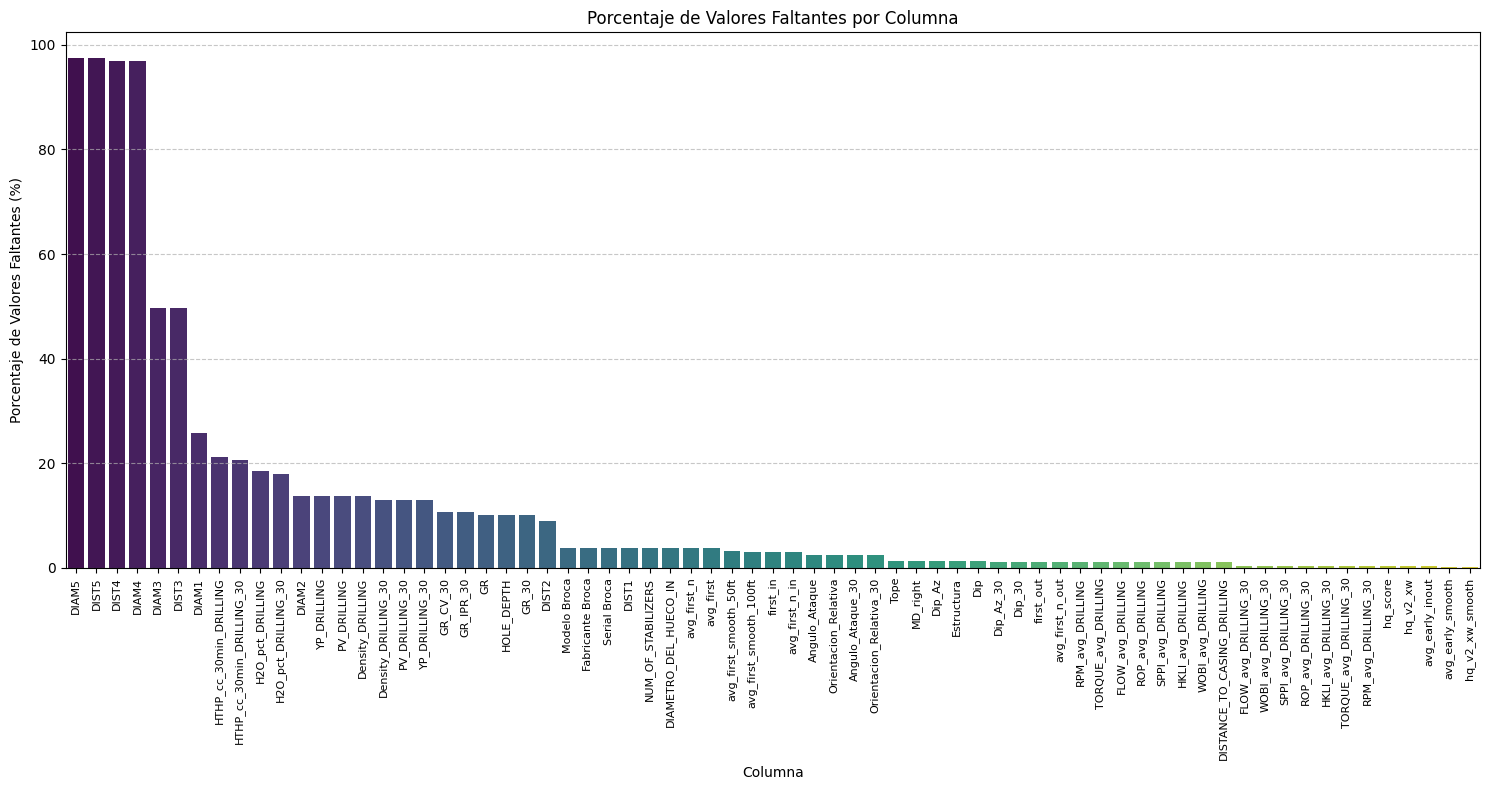

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el porcentaje de valores nulos para cada columna
missing_percentage = df.isnull().sum() / len(df) * 100

# Filtrar columnas que tienen valores nulos
columns_with_missing = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Filtrar columnas que NO tienen valores nulos (datos completos)
columns_without_missing = missing_percentage[missing_percentage == 0]

print("\nColumnas con datos completos (0% valores faltantes):\n")
if not columns_without_missing.empty:
    for col in columns_without_missing.index:
        print(f"- {col}")
else:
    print("¡Todas las columnas tienen al menos un valor faltante!")

print("\nColumnas con valores faltantes:\n")
print(columns_with_missing)

# Visualización de columnas con valores faltantes
if not columns_with_missing.empty:
    plt.figure(figsize=(15, 8))
    sns.barplot(x=columns_with_missing.index, y=columns_with_missing.values, palette='viridis')
    plt.title('Porcentaje de Valores Faltantes por Columna')
    plt.xlabel('Columna')
    plt.ylabel('Porcentaje de Valores Faltantes (%)')
    plt.xticks(rotation=90, fontsize=8) # Rotar etiquetas para mejor legibilidad
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Ajustar el layout para evitar cortes
    plt.show()
else:
    print("¡No hay columnas con valores faltantes para graficar!")

### Preparación Inicial y Listado de Pozos

In [ ]:
# Renombrar columnas clave para mayor facilidad de uso
df = df.rename(columns={'nombre_comun_del_pozo': 'Pozo', 'BIT_POSITION': 'Profundidad'})

# Obtener una lista de nombres únicos de los pozos
lista_pozos = df['Pozo'].unique().tolist()

print("Columnas renombradas: 'nombre_comun_del_pozo' a 'Pozo' y 'BIT_POSITION' a 'Profundidad'.")
print("\nLista de Pozos únicos:\n")
for pozo in lista_pozos:
    print(f"- {pozo}")

Columnas renombradas: 'nombre_comun_del_pozo' a 'Pozo' y 'BIT_POSITION' a 'Profundidad'.

Lista de Pozos únicos:

- CUPIXD45
- CUPIXD45Y
- CUPIXD45Z
- CUSIANAV31
- FIP17
- FIP17Z
- FN18
- FN18Y
- FN18Z
- FUP16
- FUP16Y
- FUP16Z
- LIRIA12
- PJP12
- PJP12Y
- PJP12Z
- PSCP11


### Gráfica de `first_in`, `first_out` y `avg_first` vs. Profundidad para el pozo FUP16 (solo Matplotlib)

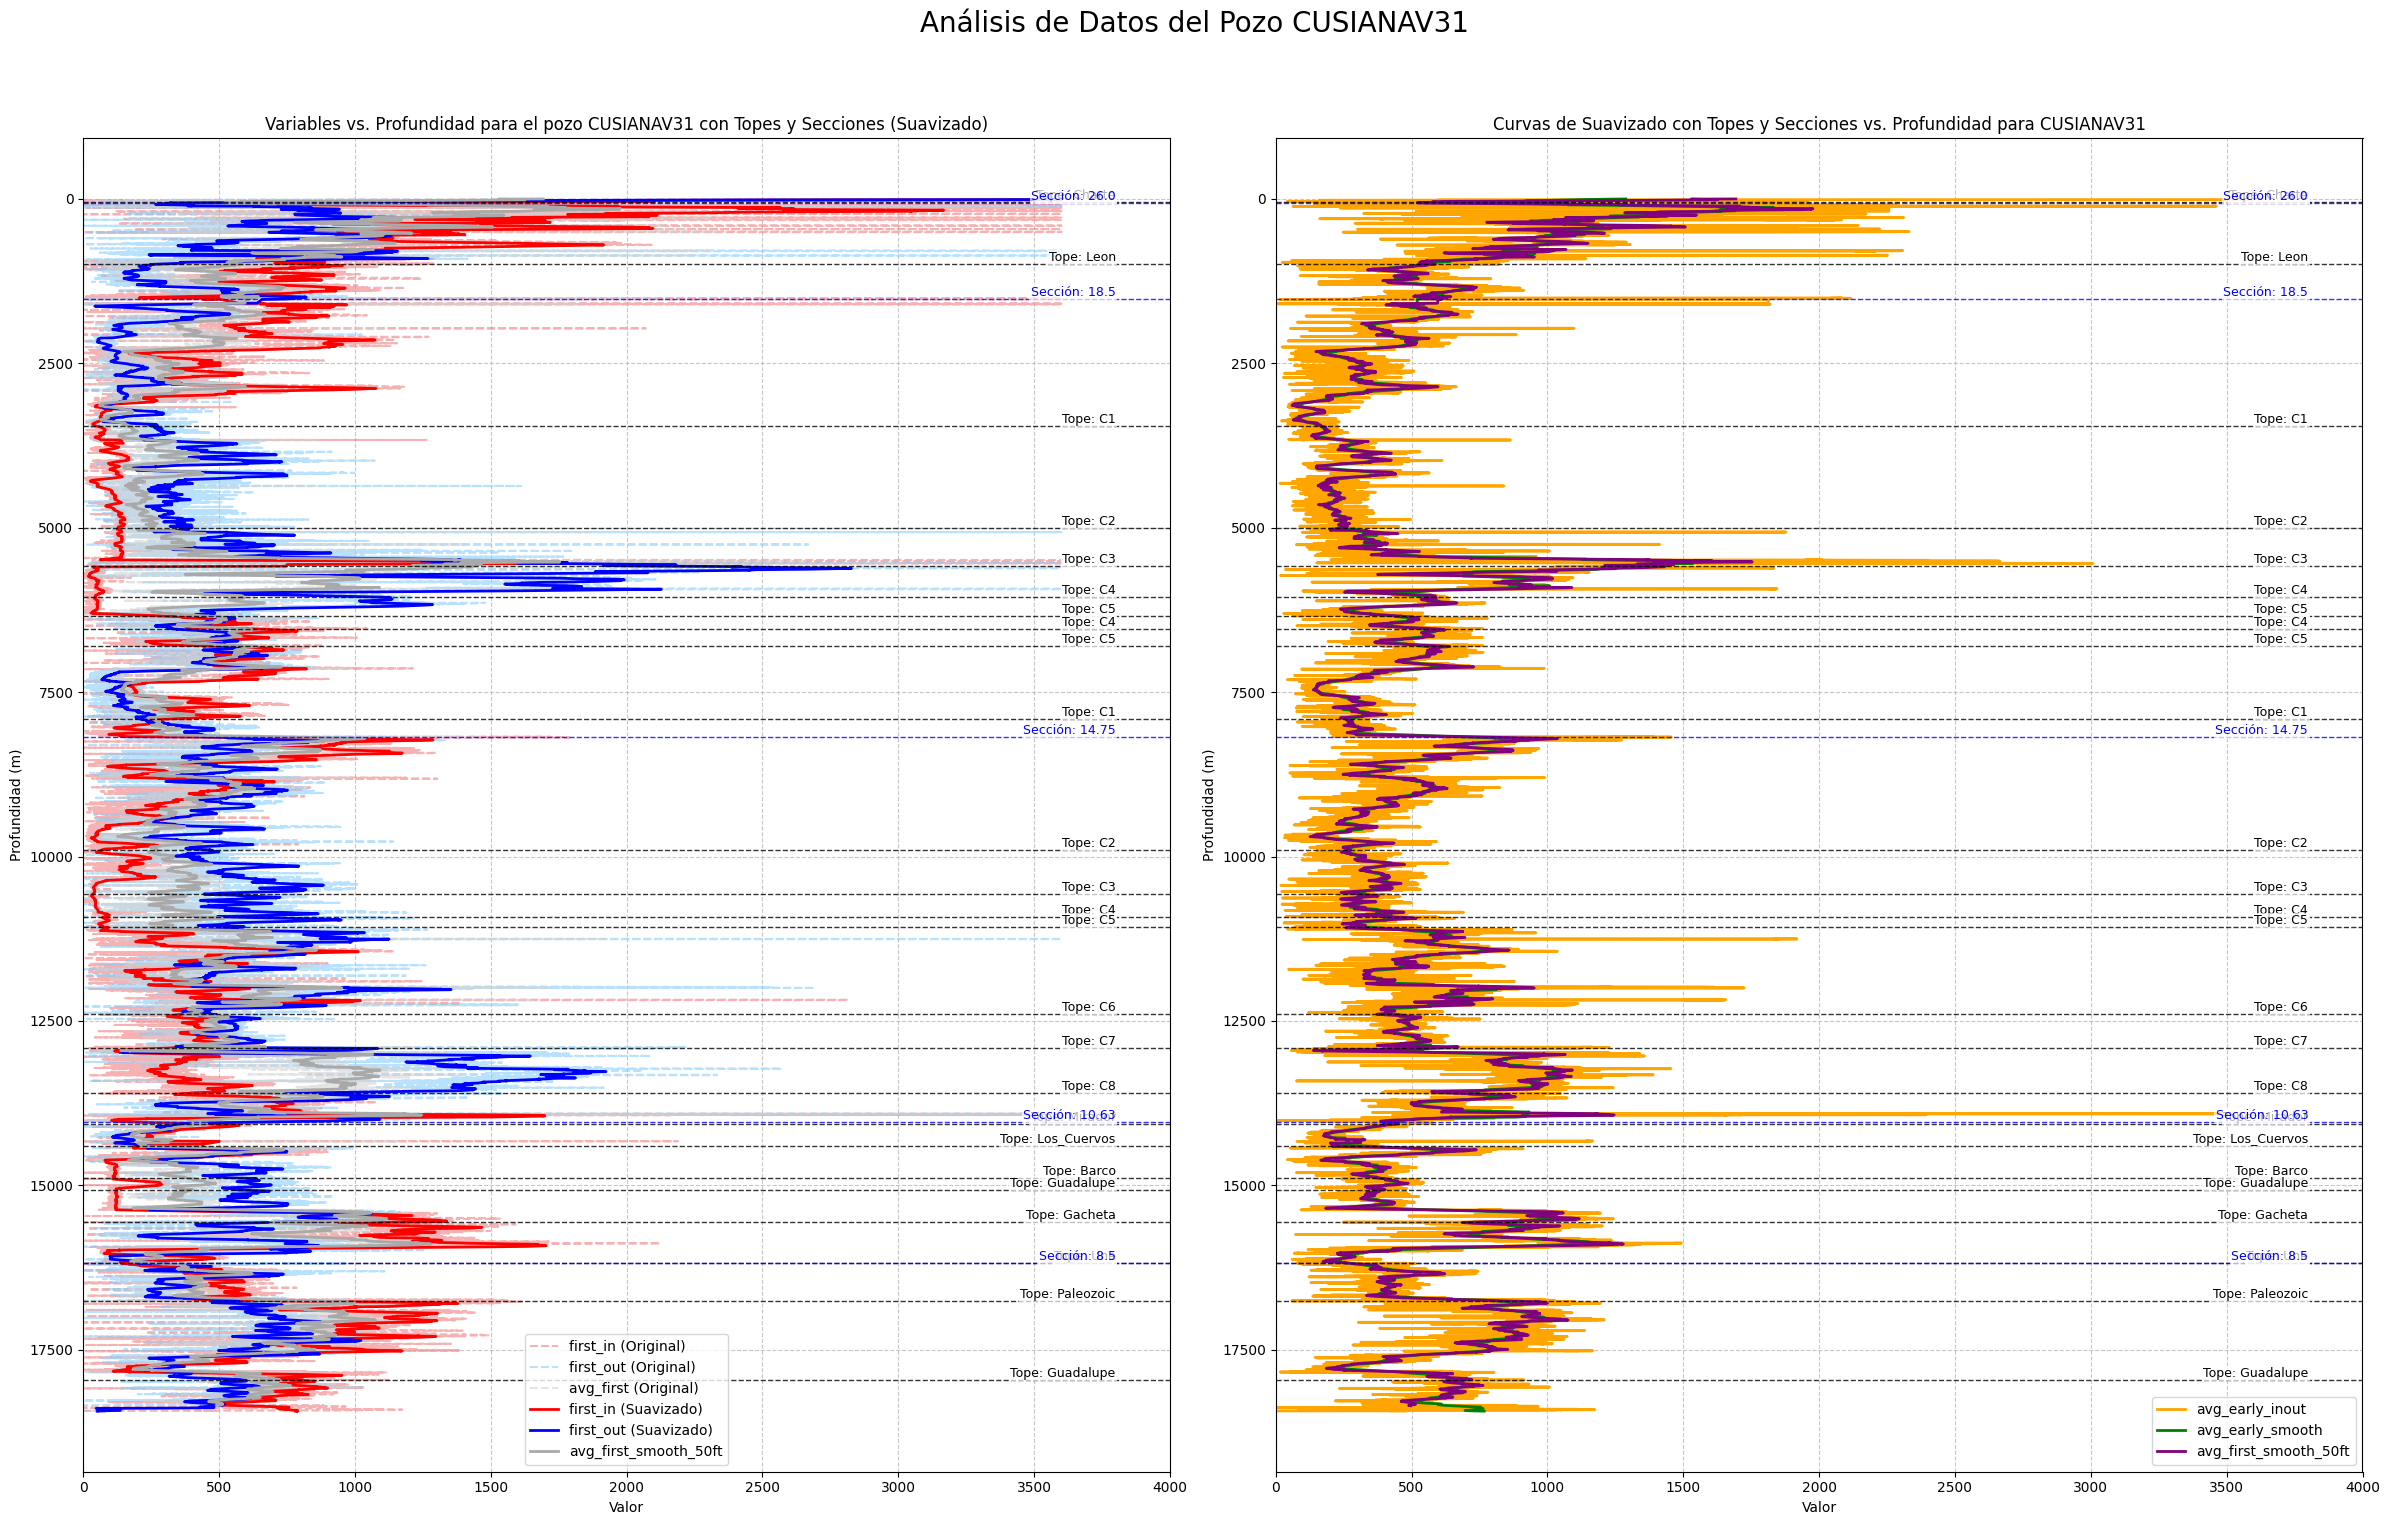

In [ ]:
import matplotlib.pyplot as plt

# Definir la ventana de suavizado
rolling_window = 50 # Puedes cambiar este valor para probar diferentes ventanas de suavizado

# Definir los límites del eje X para las velocidades (puedes ajustar estos valores)
x_min_limit = 0
x_max_limit = 4000

# Filtrar el DataFrame para el pozo
pozo_actual = 'CUSIANAV31'
df_pozo = df[df['Pozo'] == pozo_actual].copy()

# Calcular el suavizado de las columnas 'first_in' y 'first_out'
# Usar min_periods=1 para que las ventanas más pequeñas al inicio tengan valores
df_pozo['first_in_smoothed'] = df_pozo['first_in'].rolling(window=rolling_window, min_periods=1).mean()
df_pozo['first_out_smoothed'] = df_pozo['first_out'].rolling(window=rolling_window, min_periods=1).mean()

# Crear una figura con dos subplots uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(24, 16)) # Ajustar el tamaño para acomodar dos plots

# --- Primer Subplot: first_in, first_out (original y suavizado) y avg_first_smooth_50ft ---

# Definir colores para las curvas originales (suaves) y suavizadas (fuertes)
soft_colors = {
    'first_in': 'lightcoral',
    'first_out': 'lightskyblue',
    'avg_first': 'lightgray'
}
strong_colors = {
    'first_in_smoothed': 'red',
    'first_out_smoothed': 'blue',
    'avg_first_smooth_50ft': 'darkgray'
}

# Plotear las columnas originales con colores suaves y estilo de línea punteado
for col in ['first_in', 'first_out', 'avg_first']:
    axes[0].plot(df_pozo[col], df_pozo['Profundidad'], label=f'{col} (Original)',
             color=soft_colors.get(col, 'gray'), alpha=0.6, linestyle='--')

# Plotear las columnas suavizadas y avg_first_smooth_50ft con colores fuertes y estilo de línea sólido
axes[0].plot(df_pozo['first_in_smoothed'], df_pozo['Profundidad'], label='first_in (Suavizado)',
         color=strong_colors['first_in_smoothed'], linewidth=2)
axes[0].plot(df_pozo['first_out_smoothed'], df_pozo['Profundidad'], label='first_out (Suavizado)',
         color=strong_colors['first_out_smoothed'], linewidth=2)
axes[0].plot(df_pozo['avg_first_smooth_50ft'], df_pozo['Profundidad'], label='avg_first_smooth_50ft',
         color=strong_colors['avg_first_smooth_50ft'], linewidth=2)


# --- Añadir líneas horizontales para "Topes" (Formaciones) en el primer subplot ---
# Identificar cambios en la columna 'Tope'
if 'Tope' in df_pozo.columns:
    df_pozo_formacion = df_pozo.dropna(subset=['Tope'])
    formation_changes = df_pozo_formacion[df_pozo_formacion['Tope'].shift() != df_pozo_formacion['Tope']]

    for index, row in formation_changes.iterrows():
        profundidad = row['Profundidad']
        formacion_name = row['Tope']
        axes[0].axhline(y=profundidad, color='black', linestyle='--', linewidth=1, alpha=0.8)
        axes[0].text(x_max_limit - (x_max_limit - x_min_limit) * 0.05, profundidad, # Adjusted x-position for more margin
             f'Tope: {formacion_name}', color='black', verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
else:
    print(f"La columna 'Tope' no se encontró en los datos de {pozo_actual}. No se graficarán los topes.")


# --- Añadir líneas horizontales para "Secciones" (Diámetro del Hueco) en el primer subplot ---
if 'DIAMETRO_DEL_HUECO_IN' in df_pozo.columns:
    df_pozo_seccion = df_pozo.dropna(subset=['DIAMETRO_DEL_HUECO_IN'])
    section_changes = df_pozo_seccion[df_pozo_seccion['DIAMETRO_DEL_HUECO_IN'].shift() != df_pozo_seccion['DIAMETRO_DEL_HUECO_IN']]

    for index, row in section_changes.iterrows():
        profundidad = row['Profundidad']
        seccion_value = row['DIAMETRO_DEL_HUECO_IN']
        axes[0].axhline(y=profundidad, color='blue', linestyle='--', linewidth=1, alpha=0.8)
        axes[0].text(x_max_limit - (x_max_limit - x_min_limit) * 0.05, profundidad, # Adjusted x-position for more margin
             f'Sección: {seccion_value}', color='blue', verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
else:
    print(f"La columna 'DIAMETRO_DEL_HUECO_IN' no se encontró en los datos de {pozo_actual}. No se graficarán las secciones.")

axes[0].set_title(f'Variables vs. Profundidad para el pozo {pozo_actual} con Topes y Secciones (Suavizado)')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Profundidad (m)')
axes[0].invert_yaxis() # Invertir el eje Y para la profundidad
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()
axes[0].set_xlim(x_min_limit, x_max_limit) # Aplicar límites del eje X

# --- Segundo Subplot: avg_early_smooth, avg_first_smooth_50ft y avg_early_inout ---

# Reordenar y plotear las curvas
axes[1].plot(df_pozo['avg_early_inout'], df_pozo['Profundidad'], label='avg_early_inout', color='orange', linewidth=2)
axes[1].plot(df_pozo['avg_early_smooth'], df_pozo['Profundidad'], label='avg_early_smooth', color='green', linewidth=2)
axes[1].plot(df_pozo['avg_first_smooth_50ft'], df_pozo['Profundidad'], label='avg_first_smooth_50ft', color='purple', linewidth=2)

# --- Añadir líneas horizontales para "Topes" (Formaciones) en el segundo subplot ---
if 'Tope' in df_pozo.columns:
    df_pozo_formacion = df_pozo.dropna(subset=['Tope'])
    formation_changes = df_pozo_formacion[df_pozo_formacion['Tope'].shift() != df_pozo_formacion['Tope']]

    for index, row in formation_changes.iterrows():
        profundidad = row['Profundidad']
        formacion_name = row['Tope']
        axes[1].axhline(y=profundidad, color='black', linestyle='--', linewidth=1, alpha=0.8)
        axes[1].text(x_max_limit - (x_max_limit - x_min_limit) * 0.05, profundidad, # Adjusted x-position for more margin
             f'Tope: {formacion_name}', color='black', verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- Añadir líneas horizontales para "Secciones" (Diámetro del Hueco) en el segundo subplot ---
if 'DIAMETRO_DEL_HUECO_IN' in df_pozo.columns:
    df_pozo_seccion = df_pozo.dropna(subset=['DIAMETRO_DEL_HUECO_IN'])
    section_changes = df_pozo_seccion[df_pozo_seccion['DIAMETRO_DEL_HUECO_IN'].shift() != df_pozo_seccion['DIAMETRO_DEL_HUECO_IN']]

    for index, row in section_changes.iterrows():
        profundidad = row['Profundidad']
        seccion_value = row['DIAMETRO_DEL_HUECO_IN']
        axes[1].axhline(y=profundidad, color='blue', linestyle='--', linewidth=1, alpha=0.8)
        axes[1].text(x_max_limit - (x_max_limit - x_min_limit) * 0.05, profundidad, # Adjusted x-position for more margin
             f'Sección: {seccion_value}', color='blue', verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

axes[1].set_title(f'Curvas de Suavizado con Topes y Secciones vs. Profundidad para {pozo_actual}')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Profundidad (m)')
axes[1].invert_yaxis() # Invertir el eje Y para la profundidad
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()
axes[1].set_xlim(x_min_limit, x_max_limit) # Aplicar límites del eje X

fig.suptitle(f'Análisis de Datos del Pozo {pozo_actual}', fontsize=20) # Añadir título general a la figura
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el layout para evitar solapamientos y dejar espacio para el título
plt.show()

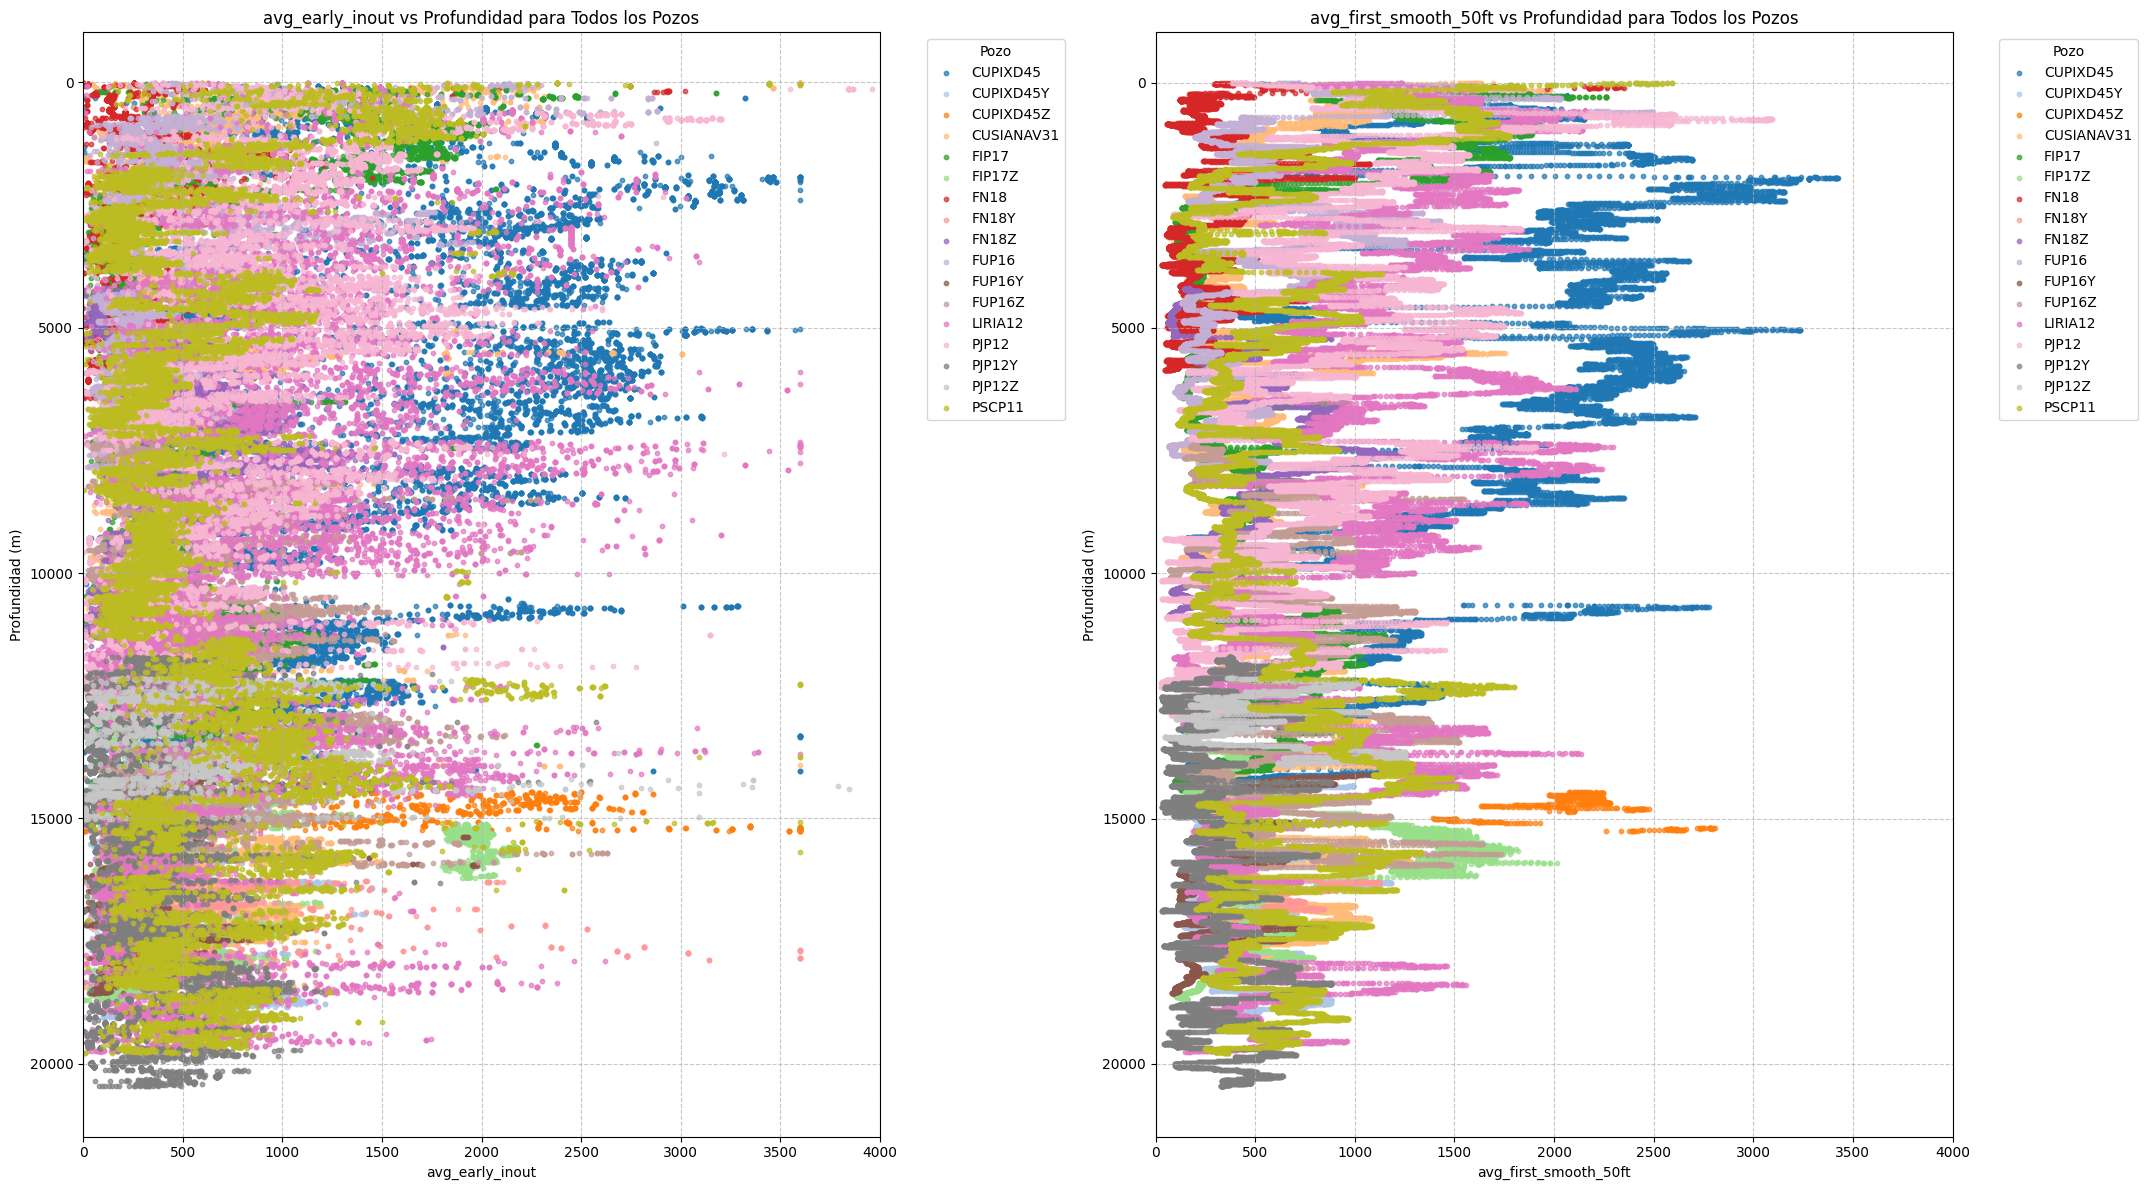

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener la lista de pozos únicos
lista_pozos = df['Pozo'].unique()

# Crear una figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Generar un mapa de colores para los pozos
colors = plt.colormaps['tab20'] # Updated to use recommended colormaps method

# Iterar sobre cada pozo y plotear los datos
for i, pozo in enumerate(lista_pozos):
    df_pozo = df[df['Pozo'] == pozo]

    # Primer Subplot: avg_early_inout vs Profundidad
    axes[0].scatter(df_pozo['avg_early_inout'], df_pozo['Profundidad'],
                    color=colors(i % colors.N), label=pozo, s=10, alpha=0.7)

    # Segundo Subplot: avg_first_smooth_50ft vs Profundidad
    axes[1].scatter(df_pozo['avg_first_smooth_50ft'], df_pozo['Profundidad'],
                    color=colors(i % colors.N), label=pozo, s=10, alpha=0.7)

# Configuración del Primer Subplot
axes[0].set_title('avg_early_inout vs Profundidad para Todos los Pozos')
axes[0].set_xlabel('avg_early_inout')
axes[0].set_ylabel('Profundidad (m)')
axes[0].invert_yaxis() # Invertir el eje Y para la profundidad
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Pozo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xlim(0, 4000) # Set x-axis limit for the first subplot

# Configuración del Segundo Subplot
axes[1].set_title('avg_first_smooth_50ft vs Profundidad para Todos los Pozos')
axes[1].set_xlabel('avg_first_smooth_50ft')
axes[1].set_ylabel('Profundidad (m)')
axes[1].invert_yaxis() # Invertir el eje Y para la profundidad
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title='Pozo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xlim(0, 4000) # Set x-axis limit for the second subplot

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Ajustar el layout para evitar solapamientos con las leyendas
plt.show()

### Suavizado de `avg_early_inout` y Cross-plot

Aquí suavizaremos la columna `avg_early_inout` por pozo y luego la compararemos con `avg_first_smooth_50ft`.

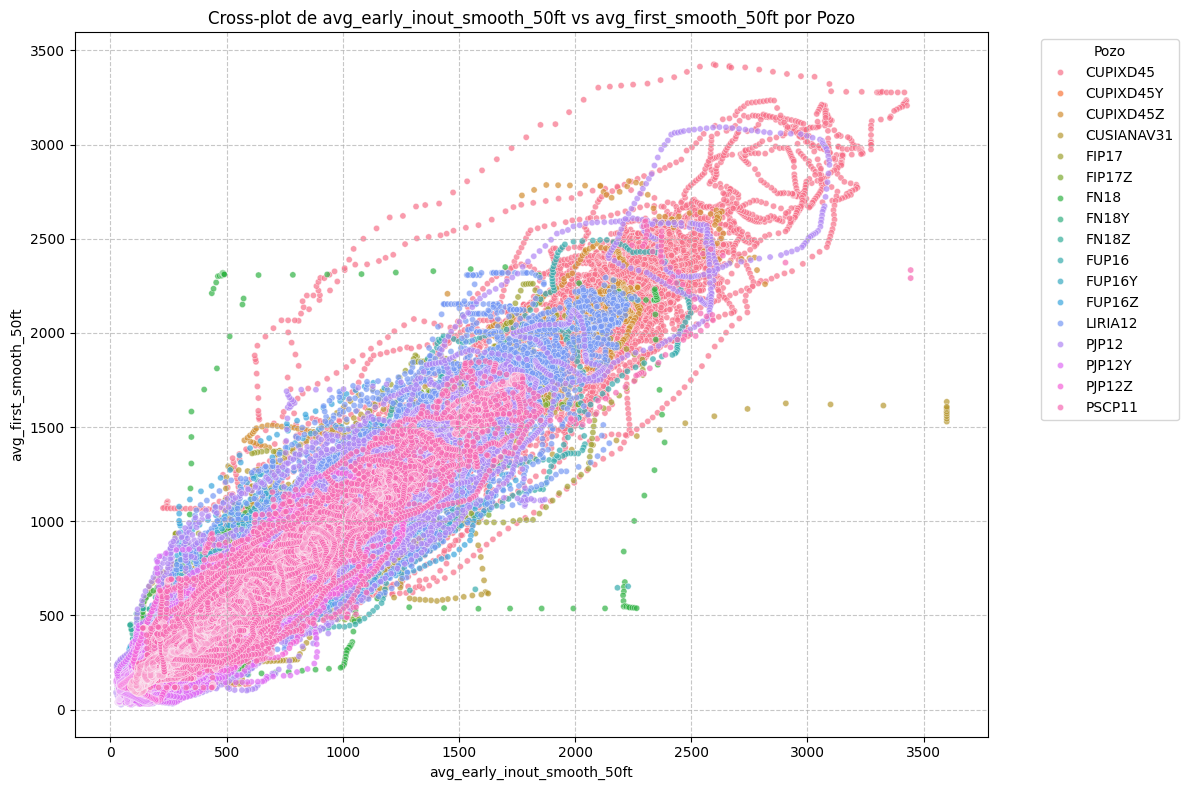

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicar suavizado a 'avg_early_inout' agrupando por 'Pozo'
# Usar min_periods=1 para que las ventanas más pequeñas al inicio tengan valores
df['avg_early_inout_smooth_50ft'] = df.groupby('Pozo')['avg_early_inout'].transform(lambda x: x.rolling(window=50, min_periods=1).mean())

# Crear el cross-plot de la nueva columna suavizada contra avg_first_smooth_50ft
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='avg_early_inout_smooth_50ft',
    y='avg_first_smooth_50ft',
    hue='Pozo', # Colorear por pozo para distinguir
    alpha=0.7,
    s=20 # Tamaño de los puntos
)

plt.title('Cross-plot de avg_early_inout_smooth_50ft vs avg_first_smooth_50ft por Pozo')
plt.xlabel('avg_early_inout_smooth_50ft')
plt.ylabel('avg_first_smooth_50ft')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pozo') # Mover leyenda fuera del plot
plt.tight_layout() # Ajustar el layout
plt.show()

### Cálculo de Percentiles P1, P99, P10 y P90 Globales para Normalización

In [ ]:
import pandas as pd

# Calcular P1, P10, P90 y P99 para avg_early_inout_smooth_50ft
p1_early_inout = df['avg_early_inout_smooth_50ft'].quantile(0.01)
p10_early_inout = df['avg_early_inout_smooth_50ft'].quantile(0.10)
p90_early_inout = df['avg_early_inout_smooth_50ft'].quantile(0.90)
p99_early_inout = df['avg_early_inout_smooth_50ft'].quantile(0.99)

# Calcular P1, P10, P90 y P99 para avg_first_smooth_50ft
p1_first_smooth = df['avg_first_smooth_50ft'].quantile(0.01)
p10_first_smooth = df['avg_first_smooth_50ft'].quantile(0.10)
p90_first_smooth = df['avg_first_smooth_50ft'].quantile(0.90)
p99_first_smooth = df['avg_first_smooth_50ft'].quantile(0.99)

print(f"Percentil P1 para avg_early_inout_smooth_50ft: {p1_early_inout:.2f}")
print(f"Percentil P10 para avg_early_inout_smooth_50ft: {p10_early_inout:.2f}")
print(f"Percentil P90 para avg_early_inout_smooth_50ft: {p90_early_inout:.2f}")
print(f"Percentil P99 para avg_early_inout_smooth_50ft: {p99_early_inout:.2f}")
print(f"Percentil P1 para avg_first_smooth_50ft: {p1_first_smooth:.2f}")
print(f"Percentil P10 para avg_first_smooth_50ft: {p10_first_smooth:.2f}")
print(f"Percentil P90 para avg_first_smooth_50ft: {p90_first_smooth:.2f}")
print(f"Percentil P99 para avg_first_smooth_50ft: {p99_first_smooth:.2f}")

# Función de normalización Min-Max con percentiles
def normalize_with_percentiles(series, p_low, p_high):
    # Asegurar que el denominador no sea cero
    if (p_high - p_low) == 0:
        return pd.Series(0, index=series.index) # O manejar como se considere adecuado para evitar divisiones por cero
    return (series - p_low) / (p_high - p_low)

# Normalizar avg_early_inout_smooth_50ft usando P1 y P90
df['avg_early_inout_normalized'] = normalize_with_percentiles(df['avg_early_inout_smooth_50ft'], p1_early_inout, p90_early_inout)

# Normalizar avg_first_smooth_50ft usando P1 y P90
df['avg_first_smooth_normalized'] = normalize_with_percentiles(df['avg_first_smooth_50ft'], p1_first_smooth, p90_first_smooth)

# Asegurarse de que los valores normalizados estén entre 0 y 1 (puede haber valores fuera del rango P1-P90)
df['avg_early_inout_normalized'] = df['avg_early_inout_normalized'].clip(0, 1)
df['avg_first_smooth_normalized'] = df['avg_first_smooth_normalized'].clip(0, 1)

print("Columnas 'avg_early_inout_normalized' y 'avg_first_smooth_normalized' creadas y normalizadas usando P1 y P90.")

# Mostrar las primeras filas con las nuevas columnas normalizadas
display(df[['Pozo', 'Profundidad', 'avg_early_inout_smooth_50ft', 'avg_first_smooth_50ft', 'avg_early_inout_normalized', 'avg_first_smooth_normalized']].head())

Percentil P1 para avg_early_inout_smooth_50ft: 78.83
Percentil P10 para avg_early_inout_smooth_50ft: 179.73
Percentil P90 para avg_early_inout_smooth_50ft: 1455.38
Percentil P99 para avg_early_inout_smooth_50ft: 2458.80
Percentil P1 para avg_first_smooth_50ft: 80.58
Percentil P10 para avg_first_smooth_50ft: 181.50
Percentil P90 para avg_first_smooth_50ft: 1469.77
Percentil P99 para avg_first_smooth_50ft: 2464.44
Columnas 'avg_early_inout_normalized' y 'avg_first_smooth_normalized' creadas y normalizadas usando P1 y P90.


,Pozo,Profundidad,avg_early_inout_smooth_50ft,avg_first_smooth_50ft,avg_early_inout_normalized,avg_first_smooth_normalized
0,CUPIXD45,31.0,315.336376,548.217700,0.171811,0.336628
1,CUPIXD45,32.0,643.189047,539.666242,0.409981,0.330472
2,CUPIXD45,33.0,548.433561,535.015300,0.341145,0.327124
3,CUPIXD45,34.0,501.055131,531.833373,0.306727,0.324833
4,CUPIXD45,35.0,486.274341,528.863574,0.295989,0.322696


### Normalización con Exclusiones Específicas

Aquí vamos a aplicar las exclusiones solicitadas para recalcular los percentiles P1 y P99, y luego normalizar las variables `avg_early_inout_smooth_50ft` y `avg_first_smooth_50ft`.

In [ ]:
# 1. Definir las condiciones de exclusión
exclusion_cond_1 = (
    (df['Pozo'] == 'CUPIXD45') &
    (df['DIAMETRO_DEL_HUECO_IN'] >= 10.6) &
    (df['DIAMETRO_DEL_HUECO_IN'] <= 10.8)
)

exclusion_cond_2 = (df['Pozo'] == 'CUPIXD45Z')

exclusion_cond_3 = (
    (df['Pozo'] == 'PJP12Z') &
    (df['Profundidad'] > 13970)
)

# Combinar todas las condiciones de exclusión
excluded_data_mask = exclusion_cond_1 | exclusion_cond_2 | exclusion_cond_3

# Crear un DataFrame filtrado TEMPORAL para el cálculo de percentiles (sin los datos excluidos)
df_temp_for_percentiles = df[~excluded_data_mask].copy()

print(f"Total de filas en el DataFrame original: {len(df)}")
print(f"Total de filas excluidas: {excluded_data_mask.sum()}")
print(f"Total de filas en el DataFrame temporal para el cálculo de percentiles: {len(df_temp_for_percentiles)}")

# 2. Recalcular P1, P10, P90 y P99 para las columnas suavizadas usando el DataFrame filtrado temporal
p1_early_inout_filtered = df_temp_for_percentiles['avg_early_inout_smooth_50ft'].quantile(0.01)
p10_early_inout_filtered = df_temp_for_percentiles['avg_early_inout_smooth_50ft'].quantile(0.10)
p90_early_inout_filtered = df_temp_for_percentiles['avg_early_inout_smooth_50ft'].quantile(0.90)
p99_early_inout_filtered = df_temp_for_percentiles['avg_early_inout_smooth_50ft'].quantile(0.99)

p1_first_smooth_filtered = df_temp_for_percentiles['avg_first_smooth_50ft'].quantile(0.01)
p10_first_smooth_filtered = df_temp_for_percentiles['avg_first_smooth_50ft'].quantile(0.10)
p90_first_smooth_filtered = df_temp_for_percentiles['avg_first_smooth_50ft'].quantile(0.90)
p99_first_smooth_filtered = df_temp_for_percentiles['avg_first_smooth_50ft'].quantile(0.99)

print("\nPercentiles calculados con datos filtrados:")
print(f"P1 avg_early_inout_smooth_50ft (filtrado): {p1_early_inout_filtered:.2f}")
print(f"P10 avg_early_inout_smooth_50ft (filtrado): {p10_early_inout_filtered:.2f}")
print(f"P90 avg_early_inout_smooth_50ft (filtrado): {p90_early_inout_filtered:.2f}")
print(f"P99 avg_early_inout_smooth_50ft (filtrado): {p99_early_inout_filtered:.2f}")
print(f"P1 avg_first_smooth_50ft (filtrado): {p1_first_smooth_filtered:.2f}")
print(f"P10 avg_first_smooth_50ft (filtrado): {p10_first_smooth_filtered:.2f}")
print(f"P90 avg_first_smooth_50ft (filtrado): {p90_first_smooth_filtered:.2f}")
print(f"P99 avg_first_smooth_50ft (filtrado): {p99_first_smooth_filtered:.2f}")

# 3. Aplicar la normalización al DataFrame ORIGINAL utilizando los percentiles P1 y P90 filtrados
# Usamos la misma función de normalización definida anteriormente
df['avg_early_inout_normalized_filtered'] = normalize_with_percentiles(df['avg_early_inout_smooth_50ft'], p1_early_inout_filtered, p90_early_inout_filtered)
df['avg_first_smooth_normalized_filtered'] = normalize_with_percentiles(df['avg_first_smooth_50ft'], p1_first_smooth_filtered, p90_first_smooth_filtered)

# Asegurarse de que los valores normalizados estén entre 0 y 1
df['avg_early_inout_normalized_filtered'] = df['avg_early_inout_normalized_filtered'].clip(0, 1)
df['avg_first_smooth_normalized_filtered'] = df['avg_first_smooth_normalized_filtered'].clip(0, 1)

print("\nNuevas columnas normalizadas ('_filtered') creadas en el DataFrame original usando P1 y P90.")

# 4. Re-crear df_filtered AHORA que el df original contiene las columnas normalizadas
#    Esto asegura que df_filtered tenga las columnas *_normalized_filtered
df_filtered = df[~excluded_data_mask].copy()

#    Lista de columnas normalizadas antiguas y duplicadas que queremos eliminar de df_filtered
columns_to_drop_from_df_filtered = [
    'avg_early_inout_normalized',
    'avg_first_smooth_normalized',
    'HQ_Index' # Asegurarse de que si ya existía por error, se elimine
]
# Eliminar estas columnas si existen en df_filtered
df_filtered = df_filtered.drop(columns=[col for col in columns_to_drop_from_df_filtered if col in df_filtered.columns], errors='ignore')

# 5. Renombrar la columna avg_early_inout_normalized_filtered a HQ_Index en df_filtered
#    Ahora que las posibles columnas conflictivas han sido eliminadas, el renombramiento será único
if 'avg_early_inout_normalized_filtered' in df_filtered.columns:
    df_filtered = df_filtered.rename(columns={'avg_early_inout_normalized_filtered': 'HQ_Index'}) # Renombrar directamente
    print("Columna 'avg_early_inout_normalized_filtered' renombrada a 'HQ_Index' en df_filtered.")
else:
    print("Error: La columna 'avg_early_inout_normalized_filtered' no se encontró en df_filtered para renombrar. No se realizó el renombramiento a HQ_Index.")

print("Columnas finales en df_filtered relevantes:")
display(df_filtered[['Pozo', 'Profundidad', 'DIAMETRO_DEL_HUECO_IN', 'avg_early_inout_smooth_50ft', 'avg_first_smooth_50ft', 'HQ_Index', 'avg_first_smooth_normalized_filtered']].head())

Total de filas en el DataFrame original: 159486
Total de filas excluidas: 1857
Total de filas en el DataFrame temporal para el cálculo de percentiles: 157629

Percentiles calculados con datos filtrados:
P1 avg_early_inout_smooth_50ft (filtrado): 80.34
P10 avg_early_inout_smooth_50ft (filtrado): 180.14
P90 avg_early_inout_smooth_50ft (filtrado): 1431.32
P99 avg_early_inout_smooth_50ft (filtrado): 2453.83
P1 avg_first_smooth_50ft (filtrado): 80.54
P10 avg_first_smooth_50ft (filtrado): 181.32
P90 avg_first_smooth_50ft (filtrado): 1450.87
P99 avg_first_smooth_50ft (filtrado): 2455.03

Nuevas columnas normalizadas ('_filtered') creadas en el DataFrame original usando P1 y P90.
Columna 'avg_early_inout_normalized_filtered' renombrada a 'HQ_Index' en df_filtered.
Columnas finales en df_filtered relevantes:


,Pozo,Profundidad,DIAMETRO_DEL_HUECO_IN,avg_early_inout_smooth_50ft,avg_first_smooth_50ft,HQ_Index,avg_first_smooth_normalized_filtered
0,CUPIXD45,31.0,NaN,315.336376,548.217700,0.173947,0.341288
1,CUPIXD45,32.0,NaN,643.189047,539.666242,0.416623,0.335047
2,CUPIXD45,33.0,NaN,548.433561,535.015300,0.346485,0.331653
3,CUPIXD45,34.0,NaN,501.055131,531.833373,0.311416,0.329331
4,CUPIXD45,35.0,NaN,486.274341,528.863574,0.300475,0.327164


### Visualización de la Distribución de `avg_early_inout_smooth_50ft` y `HQ_Index`

Vamos a graficar la distribución de estas dos columnas para evaluar su comportamiento y decidir si se requiere una normalización adicional.

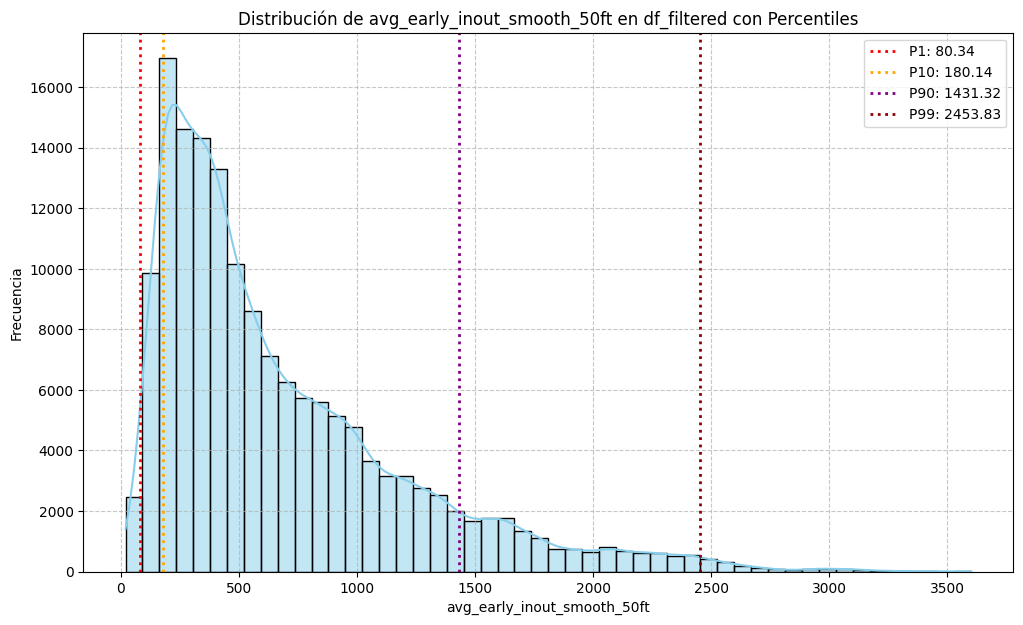

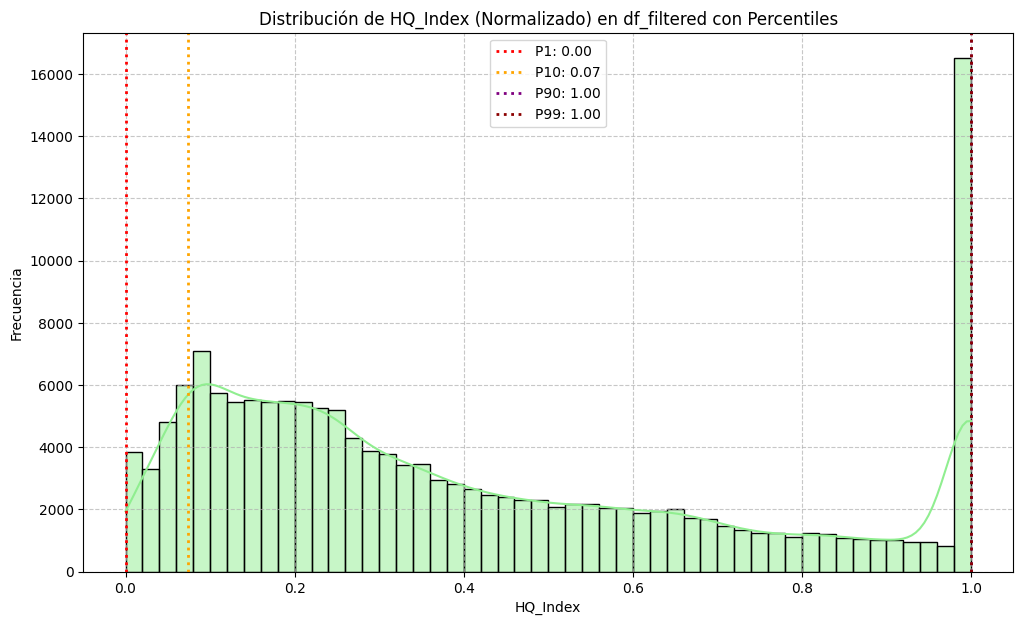

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular percentiles para avg_early_inout_smooth_50ft en df_filtered
p1_early_filtered = df_filtered['avg_early_inout_smooth_50ft'].quantile(0.01)
p10_early_filtered = df_filtered['avg_early_inout_smooth_50ft'].quantile(0.10)
p90_early_filtered = df_filtered['avg_early_inout_smooth_50ft'].quantile(0.90)
p99_early_filtered = df_filtered['avg_early_inout_smooth_50ft'].quantile(0.99)

# Plot para avg_early_inout_smooth_50ft
plt.figure(figsize=(12, 7))
sns.histplot(df_filtered['avg_early_inout_smooth_50ft'].dropna(), kde=True, bins=50, color='skyblue')
plt.title('Distribución de avg_early_inout_smooth_50ft en df_filtered con Percentiles')
plt.xlabel('avg_early_inout_smooth_50ft')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

# Añadir marcadores de percentiles al plot de avg_early_inout_smooth_50ft
plt.axvline(x=p1_early_filtered, color='red', linestyle=':', linewidth=2, label=f'P1: {p1_early_filtered:.2f}')
plt.axvline(x=p10_early_filtered, color='orange', linestyle=':', linewidth=2, label=f'P10: {p10_early_filtered:.2f}')
plt.axvline(x=p90_early_filtered, color='purple', linestyle=':', linewidth=2, label=f'P90: {p90_early_filtered:.2f}')
plt.axvline(x=p99_early_filtered, color='darkred', linestyle=':', linewidth=2, label=f'P99: {p99_early_filtered:.2f}')
plt.legend()
plt.show()

# Calcular percentiles para HQ_Index en df_filtered
p1_hq_filtered = df_filtered['HQ_Index'].quantile(0.01)
p10_hq_filtered = df_filtered['HQ_Index'].quantile(0.10)
p90_hq_filtered = df_filtered['HQ_Index'].quantile(0.90)
p99_hq_filtered = df_filtered['HQ_Index'].quantile(0.99)

# Plot para HQ_Index
plt.figure(figsize=(12, 7))
sns.histplot(df_filtered['HQ_Index'].dropna(), kde=True, bins=50, color='lightgreen')
plt.title('Distribución de HQ_Index (Normalizado) en df_filtered con Percentiles')
plt.xlabel('HQ_Index')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

# Añadir marcadores de percentiles al plot de HQ_Index
plt.axvline(x=p1_hq_filtered, color='red', linestyle=':', linewidth=2, label=f'P1: {p1_hq_filtered:.2f}')
plt.axvline(x=p10_hq_filtered, color='orange', linestyle=':', linewidth=2, label=f'P10: {p10_hq_filtered:.2f}')
plt.axvline(x=p90_hq_filtered, color='purple', linestyle=':', linewidth=2, label=f'P90: {p90_hq_filtered:.2f}')
plt.axvline(x=p99_hq_filtered, color='darkred', linestyle=':', linewidth=2, label=f'P99: {p99_hq_filtered:.2f}')
plt.legend()
plt.show()

/tmp/ipykernel_654/2293931287.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp_pozo_plot, x='HQ_Index', y='Pozo', order=ordered_pozos, ax=axes[0], palette=pozo_palette_dict)
/tmp/ipykernel_654/2293931287.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp_diam_plot_filtered, x='HQ_Index', y='DIAMETRO_DEL_HUECO_IN_STR', order=ordered_diameters_str, ax=axes[1], palette=diam_palette_dict)


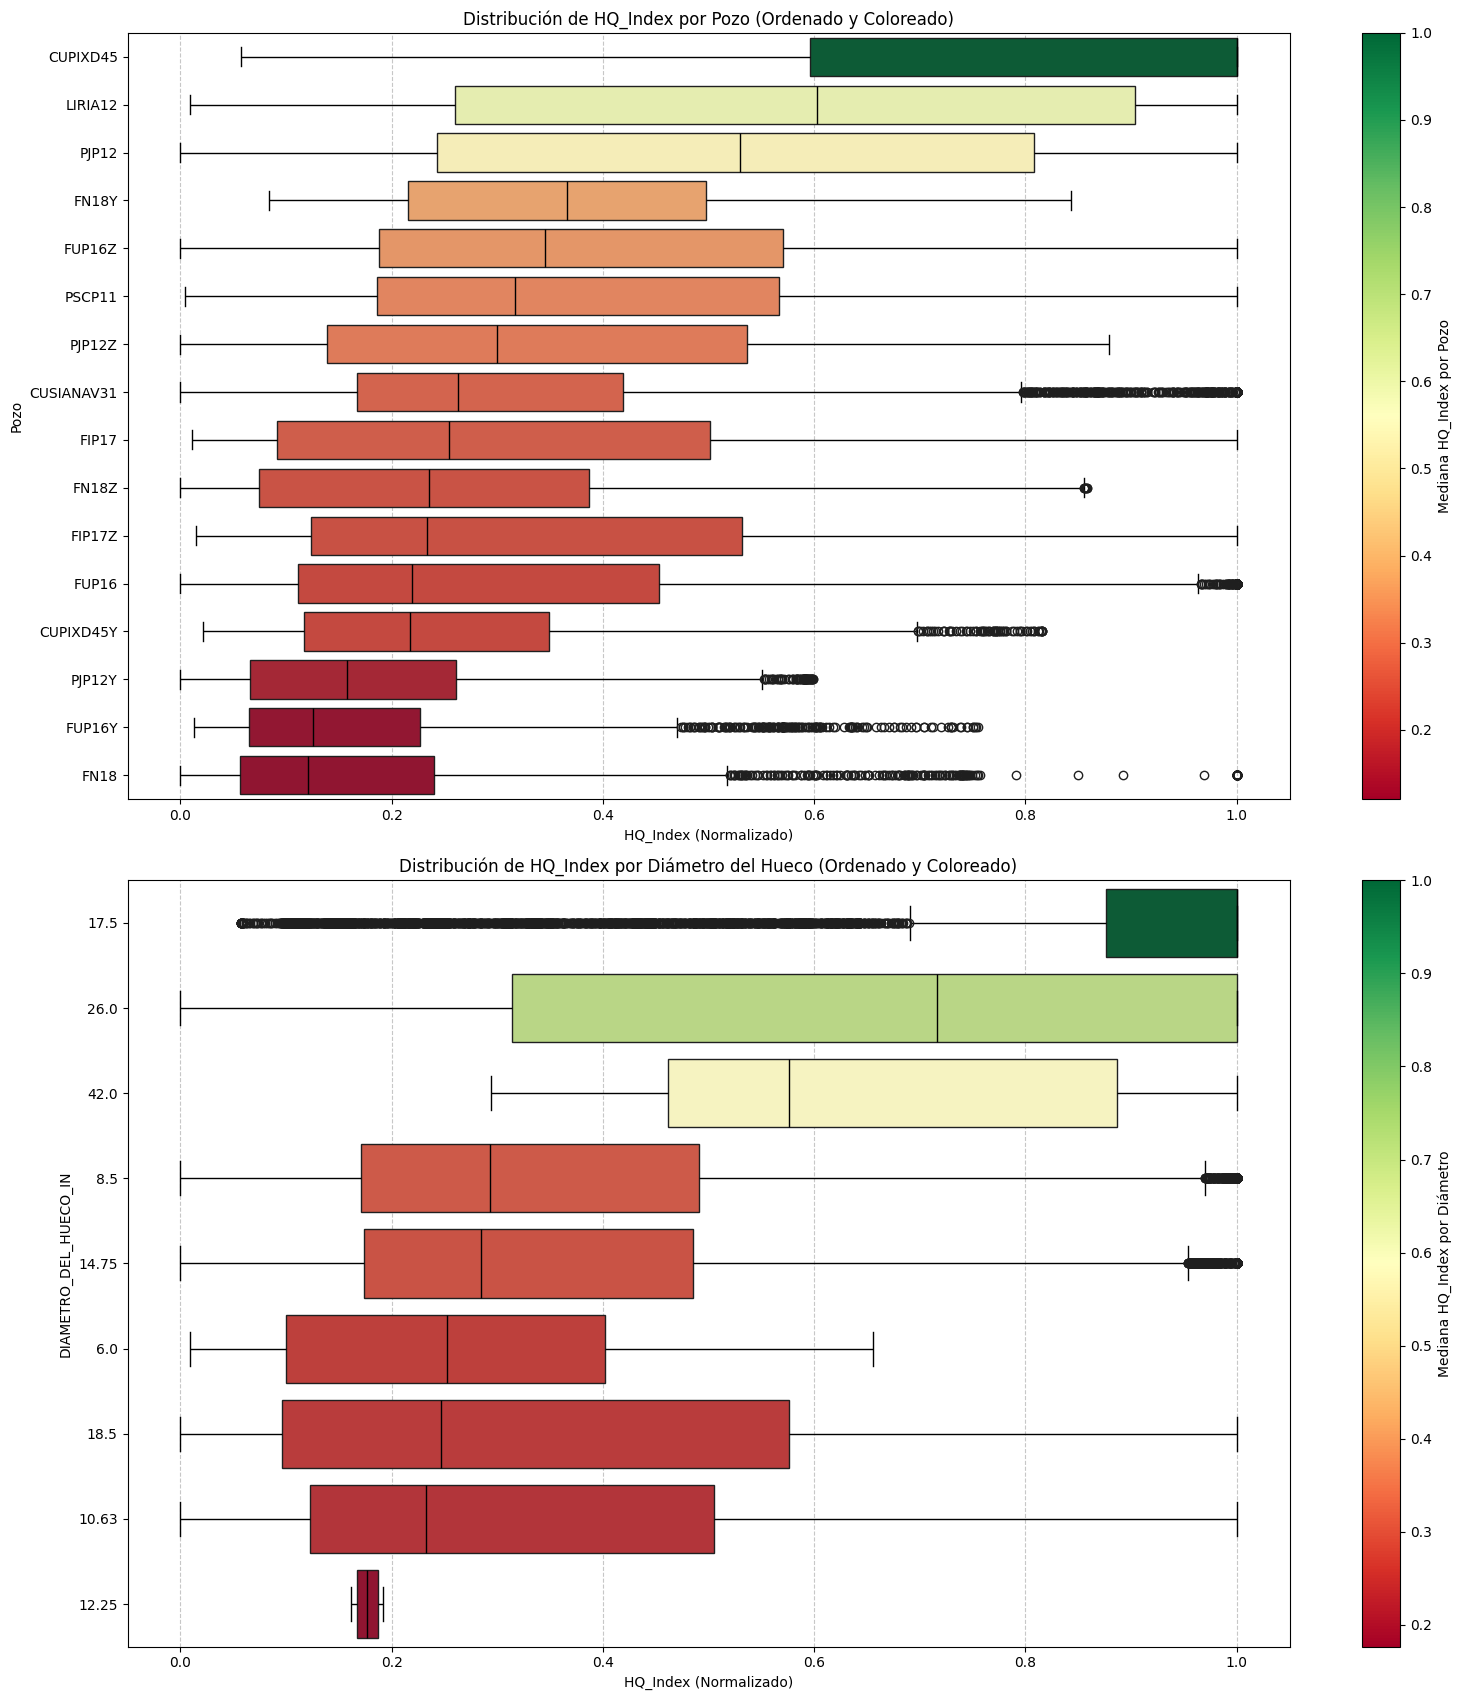

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

# Ensure 'DIAMETRO_DEL_HUECO_IN' is numeric in df_filtered
df_filtered['DIAMETRO_DEL_HUECO_IN'] = pd.to_numeric(df_filtered['DIAMETRO_DEL_HUECO_IN'], errors='coerce')

# --- Boxplot para Pozo --- #

# Create a temporary DataFrame for median calculation and plotting, ensuring no NaNs in key columns
df_temp_pozo_plot = df_filtered.dropna(subset=['HQ_Index', 'Pozo'])

# Calcular la mediana del HQ_Index para cada pozo
median_hq_index_series_pozo = df_temp_pozo_plot.groupby('Pozo')['HQ_Index'].median()
median_hq_index_df_pozo = median_hq_index_series_pozo.reset_index(name='Median_HQ_Index')
median_hq_index_sorted_pozo = median_hq_index_df_pozo.sort_values(by='Median_HQ_Index', ascending=False)
ordered_pozos = median_hq_index_sorted_pozo['Pozo'].tolist()
median_values_for_colors_pozo = median_hq_index_sorted_pozo.set_index('Pozo')['Median_HQ_Index']

# Crear paleta de colores para pozos
min_median_pozo = median_values_for_colors_pozo.min()
max_median_pozo = median_values_for_colors_pozo.max()

cmap_pozo_obj = plt.colormaps["RdYlGn"] # Get the colormap object

# Handle case where all medians are the same (to avoid division by zero in Normalize)
if min_median_pozo == max_median_pozo:
    norm_pozo = mcolors.Normalize(vmin=0, vmax=1) # Generic normalization
    pozo_colors_list = [cmap_pozo_obj(0.5) for _ in ordered_pozos] # Assign a neutral color list
else:
    norm_pozo = mcolors.Normalize(vmin=min_median_pozo, vmax=max_median_pozo)
    pozo_colors_list = [cmap_pozo_obj(norm_pozo(median_values_for_colors_pozo[pozo])) for pozo in ordered_pozos]

sm_pozo = plt.cm.ScalarMappable(cmap=cmap_pozo_obj, norm=norm_pozo) # Still need for colorbar
sm_pozo.set_array([])

# Create a dictionary palette for seaborn
pozo_palette_dict = {pozo: color for pozo, color in zip(ordered_pozos, pozo_colors_list)}


# --- Boxplot para DIAMETRO_DEL_HUECO_IN --- #

# Create a temporary DataFrame for median calculation and plotting, ensuring no NaNs in key columns
df_temp_diam_plot = df_filtered.dropna(subset=['HQ_Index', 'DIAMETRO_DEL_HUECO_IN'])

# Ensure enough data points for each diameter to create a boxplot
diameter_counts = df_temp_diam_plot.groupby('DIAMETRO_DEL_HUECO_IN')['HQ_Index'].count()
valid_diameters = diameter_counts[diameter_counts >= 5].index.tolist() # Only include diameters with >= 5 data points

# Filter df_temp_diam_plot to only include valid diameters for plotting
df_temp_diam_plot_filtered = df_temp_diam_plot[df_temp_diam_plot['DIAMETRO_DEL_HUECO_IN'].isin(valid_diameters)].copy()

# Calcular la mediana del HQ_Index para cada DIAMETRO_DEL_HUECO_IN en el conjunto filtrado
median_hq_index_series_diam = df_temp_diam_plot_filtered.groupby('DIAMETRO_DEL_HUECO_IN')['HQ_Index'].median()
median_hq_index_df_diam = median_hq_index_series_diam.reset_index(name='Median_HQ_Index')
median_hq_index_sorted_diam = median_hq_index_df_diam.sort_values(by='Median_HQ_Index', ascending=False)

# This list will define the order of categories in the boxplot (numeric values)
ordered_diameters = median_hq_index_sorted_diam['DIAMETRO_DEL_HUECO_IN'].tolist()
median_values_for_colors_diam = median_hq_index_sorted_diam.set_index('DIAMETRO_DEL_HUECO_IN')['Median_HQ_Index']

# Create a string version of the diameter column for plotting (to avoid seaborn's numeric-categorical issues)
df_temp_diam_plot_filtered['DIAMETRO_DEL_HUECO_IN_STR'] = df_temp_diam_plot_filtered['DIAMETRO_DEL_HUECO_IN'].astype(str)
ordered_diameters_str = [str(d) for d in ordered_diameters]

# Crear paleta de colores para diámetros (using original numeric diameters for median lookup)
min_median_diam = median_values_for_colors_diam.min()
max_median_diam = median_values_for_colors_diam.max()

cmap_diam_obj = plt.colormaps["RdYlGn"] # Get the colormap object

# Handle case where all medians are the same
if min_median_diam == max_median_diam:
    norm_diam = mcolors.Normalize(vmin=0, vmax=1)
    diameter_colors_list = [cmap_diam_obj(0.5) for _ in ordered_diameters] # Use original ordered_diameters for length
else:
    norm_diam = mcolors.Normalize(vmin=min_median_diam, vmax=max_median_diam)
    diameter_colors_list = [cmap_diam_obj(norm_diam(median_values_for_colors_diam[diam])) for diam in ordered_diameters]

sm_diam = plt.cm.ScalarMappable(cmap=cmap_diam_obj, norm=norm_diam) # Still need for colorbar
sm_diam.set_array([])

# Create a dictionary palette for seaborn
diam_palette_dict = {diam_str: color for diam_str, color in zip(ordered_diameters_str, diameter_colors_list)}


# Crear figura con dos subplots, uno encima del otro
fig, axes = plt.subplots(2, 1, figsize=(16, 18))

# --- Primer Subplot: HQ_Index vs Pozo ---
sns.boxplot(data=df_temp_pozo_plot, x='HQ_Index', y='Pozo', order=ordered_pozos, ax=axes[0], palette=pozo_palette_dict)
# Loop to ensure all boxplot components have black edges if not set by palette
for i, box in enumerate(axes[0].artists):
    # Each boxplot artist includes the box, median, whiskers, and caps
    # The 'box' artist is typically a PathPatch or Rectangle
    if isinstance(box, plt.patches.PathPatch) or isinstance(box, plt.patches.Rectangle):
        box.set_edgecolor('black')
# Iterate over all median lines to set them black (often these are separate Line2D objects)
for median in axes[0].lines:
    if median.get_linestyle() == '-' and median.get_xdata().size > 1: # Check for horizontal median line
        median.set_color('black')

axes[0].set_title('Distribución de HQ_Index por Pozo (Ordenado y Coloreado)')
axes[0].set_xlabel('HQ_Index (Normalizado)')
axes[0].set_ylabel('Pozo')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Añadir barra de color para el primer subplot (Pozos)
cbar_pozo = fig.colorbar(sm_pozo, ax=axes[0])
cbar_pozo.set_label('Mediana HQ_Index por Pozo')

# --- Segundo Subplot: HQ_Index vs DIAMETRO_DEL_HUECO_IN ---
sns.boxplot(data=df_temp_diam_plot_filtered, x='HQ_Index', y='DIAMETRO_DEL_HUECO_IN_STR', order=ordered_diameters_str, ax=axes[1], palette=diam_palette_dict)
# Loop to ensure all boxplot components have black edges if not set by palette
for i, box in enumerate(axes[1].artists):
    if isinstance(box, plt.patches.PathPatch) or isinstance(box, plt.patches.Rectangle):
        box.set_edgecolor('black')
# Iterate over all median lines to set them black
for median in axes[1].lines:
    if median.get_linestyle() == '-' and median.get_xdata().size > 1:
        median.set_color('black')

axes[1].set_title('Distribución de HQ_Index por Diámetro del Hueco (Ordenado y Coloreado)')
axes[1].set_xlabel('HQ_Index (Normalizado)')
axes[1].set_ylabel('DIAMETRO_DEL_HUECO_IN')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Añadir barra de color para el segundo subplot (Diámetros)
cbar_diam = fig.colorbar(sm_diam, ax=axes[1])
cbar_diam.set_label('Mediana HQ_Index por Diámetro')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar el layout
plt.show()